In [1]:
# 1. Standard Library Imports
import os
import io
import time
import zipfile
import warnings
from random import randint
from pathlib import Path

# 2. Third-Party Data Processing
import pandas as pd
import numpy as np
import requests
import urllib3
from urllib3.util import retry

# 3. Modeling & Machine Learning
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    precision_recall_curve, 
    confusion_matrix
)
from sklearn.inspection import permutation_importance # Used for feature importance

# 4. Visualization
import matplotlib.pyplot as plt
import seaborn as sns
try:
    import shap # Optional: For advanced interpretability
except ImportError:
    pass

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
DATA_DIR = Path('Internal data')

In [2]:
# ==============================================================================
# SECTION 1: EXTERNAL DATA ACQUISITION PIPELINE
# ==============================================================================
# OVERVIEW:
# 1. Health Canada DPD: Static regulatory data (Therapeutic Class, Route).
# 2. Google Trends: Dynamic consumer sentiment index (Panic/Demand signals).
# ==============================================================================

# 1. API Configuration & Network Initialization
# ------------------------------------------------------------------------------
# Configure network adapters to ensure stable API connections
if not hasattr(retry.Retry, '_original_init'):
    retry.Retry._original_init = retry.Retry.__init__

def patched_init(self, *args, **kwargs):
    # Ensure compatibility across different urllib3 versions
    if 'method_whitelist' in kwargs:
        kwargs['allowed_methods'] = kwargs.pop('method_whitelist')
    self._original_init(*args, **kwargs)

retry.Retry.__init__ = patched_init

try:
    from pytrends.request import TrendReq
    PYTRENDS_ACTIVE = True
except ImportError:
    PYTRENDS_ACTIVE = False
    print("  [Info] Google Trends API library not found. Using simulation mode.")

# ------------------------------------------------------------------------------
# PART A: HEALTH CANADA DRUG PRODUCT DATABASE (DPD)
# ------------------------------------------------------------------------------
def fetch_health_canada_data(output_dir):
    """
    Downloads regulatory files from Health Canada.
    Extracts: Therapeutic Class, Route of Administration, and Schedule.
    """
    base_url = "https://www.canada.ca/content/dam/hc-sc/migration/hc-sc/dhp-mps/alt_formats/zip/prodpharma/databasdon/"
    targets = {
        "allfiles.zip": ["drug.txt", "ingred.txt", "route.txt", "ther.txt", "schedule.txt"], 
        "allfiles_ia.zip": ["drug_ia.txt", "ingred_ia.txt", "route_ia.txt", "ther_ia.txt", "schedule_ia.txt"]
    }

    print("\n[Pipeline] Acquiring Health Canada Regulatory Data...")
    
    for zip_name, files in targets.items():
        if all((output_dir / f).exists() for f in files):
            print(f"  > Validating local files: {zip_name} (OK)")
            continue
            
        print(f"  > Downloading remote archive: {zip_name}...")
        try:
            r = requests.get(base_url + zip_name)
            r.raise_for_status()
            with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                for target in files:
                    match = next((f for f in z.namelist() if f.lower() == target.lower()), None)
                    if match: z.extract(match, output_dir)
        except Exception as e:
            print(f"  > Warning: Download failed for {zip_name} ({e})")

# ------------------------------------------------------------------------------
# PART B: GOOGLE TRENDS CONSUMER SENTIMENT INDEX
# ------------------------------------------------------------------------------
def fetch_google_trends_data(output_dir):
    """
    Acquires search volume data for 15 ATC therapeutic categories.
    Uses a 'Composite Index' strategy (MAX volume across related keywords)
    to capture high-fidelity demand signals.
    """
    output_file = output_dir / "ATC_COMPOSITE_TRENDS.csv"
    
    print("\n[Pipeline] Acquiring Consumer Sentiment Data (Google Trends)...")
    
    # Define Keyword Clusters (ATC Level 1 Mapping)
    # Strategy: Monitor aggregated search volume for broad drug categories.
    ATC_CLUSTERS = {
        'A': ['Stomach pain', 'Ozempic', 'Antacid', 'Digestive health'],
        'B': ['Blood thinner', 'Anticoagulant', 'Blood clot'],
        'C': ['Blood pressure', 'Heart medication', 'Beta blocker'],
        'D': ['Eczema cream', 'Skin rash', 'Cortisone'],
        'G': ['Birth control', 'Hormone replacement', 'Menopause'],
        'H': ['Thyroid medicine', 'Steroids', 'Prednisone'],
        'J': ['Antibiotics', 'Amoxicillin', 'Penicillin', 'Infection med'],
        'L': ['Chemotherapy', 'Cancer treatment', 'Immunotherapy'],
        'M': ['Muscle pain', 'Back pain', 'Arthritis relief'],
        'N': ['Pain killer', 'Tylenol', 'Advil', 'Ibuprofen'],
        'P': ['Lice treatment', 'Worm medicine'],
        'R': ['Cold medicine', 'Cough syrup', 'Flu medicine', 'Inhaler'],
        'S': ['Eye drops', 'Pink eye', 'Ear drops'],
        'V': ['Medical supply', 'First aid'],
        'X': ['Natural remedy', 'Herbal medicine', 'Vitamins'],
        'U': ['Pharmacy shortage', 'Medicine out of stock']
    }

    fetched_data = None

    # 1. Attempt API Connection
    if PYTRENDS_ACTIVE:
        try:
            print("  > Connecting to Google Trends API (Geo: Canada, Timeframe: 5y)...")
            pytrends = TrendReq(hl='en-US', tz=360, timeout=(10,25), retries=2, backoff_factor=0.1)
            batch_results = []
            
            for idx, (atc, keywords) in enumerate(ATC_CLUSTERS.items()):
                print(f"    Processing Cluster {idx+1}/{len(ATC_CLUSTERS)}: '{atc}'")
                pytrends.build_payload(keywords, cat=0, timeframe='today 5-y', geo='CA')
                data = pytrends.interest_over_time()
                
                if not data.empty:
                    data = data.drop(columns=['isPartial'], errors='ignore')
                    # Calculate Composite Index (Max Signal Strength)
                    data['COMPOSITE_INDEX'] = data.max(axis=1)
                    subset = data.reset_index()[['date', 'COMPOSITE_INDEX']]
                    subset['ATC_LEVEL1'] = atc
                    batch_results.append(subset)
                
                time.sleep(randint(2, 4)) # Rate limit compliance
            
            if batch_results:
                fetched_data = pd.concat(batch_results)
                fetched_data['YEAR_WEEK'] = fetched_data['date'].dt.strftime('%Y%U').astype(int)
                print("  > [Success] Real-world sentiment data acquired.")
                
        except Exception:
            print("  > [Info] API unavailable. Proceeding to simulation mode.")

    # 2. Simulation Mode (Fallback)
    # Generates realistic seasonal patterns if API is unreachable (e.g., offline)
    if fetched_data is None or fetched_data.empty:
        print("  > Generating Synthetic Sentiment Index (Simulation Mode)...")
        dates = pd.date_range(start='2019-01-01', end=pd.Timestamp.now(), freq='W')
        weeks = dates.strftime('%Y%U').astype(int)
        sim_batches = []
        
        for atc in ATC_CLUSTERS.keys():
            # Base demand
            signal = np.random.normal(20, 5, size=len(weeks))
            # Apply Seasonality to Respiratory/Antibiotics/Pain
            if atc in ['R', 'J', 'N']:
                season = 20 * np.sin(2 * np.pi * dates.dayofyear / 365.25 + np.pi/2)
                signal += np.where(season > 5, season, 0)
            
            signal = np.clip(signal, 0, 100)
            df_sim = pd.DataFrame({'date': dates, 'YEAR_WEEK': weeks, 'ATC_LEVEL1': atc, 'COMPOSITE_INDEX': signal})
            sim_batches.append(df_sim)
        fetched_data = pd.concat(sim_batches)

    # 3. Save Artifact
    fetched_data.to_csv(output_file, index=False)
    print(f"  > Data pipeline complete. Artifact saved: {output_file}")


# ==============================================================================
# EXECUTION
# ==============================================================================
fetch_health_canada_data(DATA_DIR)
fetch_google_trends_data(DATA_DIR)
print("\nStatus: External Data Acquisition Completed Successfully.")


[Pipeline] Acquiring Health Canada Regulatory Data...
  > Validating local files: allfiles.zip (OK)
  > Validating local files: allfiles_ia.zip (OK)

[Pipeline] Acquiring Consumer Sentiment Data (Google Trends)...
  > Connecting to Google Trends API (Geo: Canada, Timeframe: 5y)...
    Processing Cluster 1/16: 'A'
    Processing Cluster 2/16: 'B'
    Processing Cluster 3/16: 'C'
    Processing Cluster 4/16: 'D'
    Processing Cluster 5/16: 'G'
    Processing Cluster 6/16: 'H'
    Processing Cluster 7/16: 'J'
    Processing Cluster 8/16: 'L'
    Processing Cluster 9/16: 'M'
    Processing Cluster 10/16: 'N'
    Processing Cluster 11/16: 'P'
    Processing Cluster 12/16: 'R'
    Processing Cluster 13/16: 'S'
    Processing Cluster 14/16: 'V'
    Processing Cluster 15/16: 'X'
    Processing Cluster 16/16: 'U'
  > [Success] Real-world sentiment data acquired.
  > Data pipeline complete. Artifact saved: Internal data/ATC_COMPOSITE_TRENDS.csv

Status: External Data Acquisition Completed Succ

In [12]:
# ==============================================================================
# SECTION 2: DATA LOADING & PRE-PROCESSING
# ==============================================================================
print("Status: Loading and Cleaning Data...")

def load_csv(filename):
    path = DATA_DIR / filename
    if path.exists():
        return pd.read_csv(path, low_memory=False) 
    else:
        print(f"Warning: File {filename} not found in {DATA_DIR}")
        return pd.DataFrame()

def process_master_dpd():
    """
    Parses DPD files to extract:
    1. AIG Size (Substitutability)
    2. Therapeutic Class (ATC Level 1)
    3. Route of Administration
    4. Prescription Status
    """
    # Define Column Schemas
    cols_drug = ['DRUG_CODE', 'PROD_CATEG', 'CLASS', 'DIN', 'BRAND_NAME', 'DESCRIPTOR', 'PEDIATRIC_FLAG', 'ACCESSION_NUMBER', 'NUMBER_OF_AIS', 'LAST_UPDATE_DATE', 'AI_GROUP_NO', 'CLASS_F', 'BRAND_NAME_F', 'DESCRIPTOR_F']
    cols_ingred = ['DRUG_CODE', 'ACTIVE_INGREDIENT_CODE', 'INGREDIENT', 'INGREDIENT_SUPPLIED_IND', 'STRENGTH', 'STRENGTH_UNIT', 'STRENGTH_TYPE', 'DOSAGE_VALUE', 'BASE', 'YESNO', 'NOTES', 'INGREDIENT_F', 'STRENGTH_UNIT_F', 'STRENGTH_TYPE_F', 'DOSAGE_VALUE_F']
    cols_route = ['DRUG_CODE', 'ROUTE_OF_ADMINISTRATION_CODE', 'ROUTE_OF_ADMINISTRATION', 'ROUTE_F']
    cols_ther = ['DRUG_CODE', 'TC_ATC_NUMBER', 'TC_ATC', 'TC_ATC_F', 'TC_AHFS_NUMBER', 'TC_AHFS', 'TC_AHFS_F']
    cols_sched = ['DRUG_CODE', 'SCHEDULE', 'SCHEDULE_F']

    def read_stack(f1, f2, cols):
        dfs = []
        for f in [f1, f2]:
            p = DATA_DIR / f
            if p.exists():
                try: dfs.append(pd.read_csv(p, names=cols, header=None, quotechar='"', encoding='latin1'))
                except: continue
        return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

    print("  > Processing Health Canada DPD Tables...")
    df_drug = read_stack("drug.txt", "drug_ia.txt", cols_drug)
    df_ingred = read_stack("ingred.txt", "ingred_ia.txt", cols_ingred)
    df_route = read_stack("route.txt", "route_ia.txt", cols_route)
    df_ther = read_stack("ther.txt", "ther_ia.txt", cols_ther)
    df_sched = read_stack("schedule.txt", "schedule_ia.txt", cols_sched)

    if df_drug.empty: return None

    # Base Cleaning & Human Filter
    df_drug['DIN'] = pd.to_numeric(df_drug['DIN'], errors='coerce')
    df_drug = df_drug.dropna(subset=['DIN'])
    df_drug['DIN'] = df_drug['DIN'].astype(int)
    df_base = df_drug[df_drug['CLASS'] == 'Human'][['DRUG_CODE', 'DIN', 'AI_GROUP_NO']].copy()

    # Feature 1: AIG Size
    aig_counts = df_base.groupby('AI_GROUP_NO')['DIN'].nunique().reset_index(name='AIG_SIZE')
    df_base = df_base.merge(aig_counts, on='AI_GROUP_NO', how='left').fillna({'AIG_SIZE': 1})

    # Feature 2: ATC Class (Level 1)
    if not df_ther.empty:
        df_ther['ATC_LEVEL1'] = df_ther['TC_ATC_NUMBER'].astype(str).str[0].str.upper()
        df_ther = df_ther[df_ther['ATC_LEVEL1'].str.isalpha()]
        ther_agg = df_ther.groupby('DRUG_CODE')['ATC_LEVEL1'].first().reset_index()
        df_base = df_base.merge(ther_agg, on='DRUG_CODE', how='left').fillna({'ATC_LEVEL1': 'X'})
    else: df_base['ATC_LEVEL1'] = 'X'

    # Feature 3: Route of Administration
    if not df_route.empty:
        def classify_route(r):
            r = str(r).upper()
            if any(x in r for x in ['INJECTION', 'INTRAVENOUS', 'PARENTERAL']): return 'INJECTION'
            if any(x in r for x in ['ORAL', 'TABLET', 'CAPSULE']): return 'ORAL'
            if any(x in r for x in ['TOPICAL', 'CREAM', 'OINTMENT']): return 'TOPICAL'
            return 'OTHER'
        df_route['ROUTE_CAT'] = df_route['ROUTE_OF_ADMINISTRATION'].apply(classify_route)
        route_agg = df_route.sort_values('ROUTE_CAT').groupby('DRUG_CODE')['ROUTE_CAT'].first().reset_index()
        df_base = df_base.merge(route_agg, on='DRUG_CODE', how='left').fillna({'ROUTE_CAT': 'OTHER'})
    else: df_base['ROUTE_CAT'] = 'OTHER'

    # Feature 4: Prescription Status
    if not df_sched.empty:
        def classify_sched(s):
            s = str(s).upper()
            if 'NARCOTIC' in s or 'CONTROLLED' in s: return 'NARCOTIC'
            if 'SCHEDULE' in s or 'PRESCRIPTION' in s: return 'RX'
            return 'OTC'
        df_sched['RX_STATUS'] = df_sched['SCHEDULE'].apply(classify_sched)
        sched_agg = df_sched.sort_values('RX_STATUS').groupby('DRUG_CODE')['RX_STATUS'].first().reset_index()
        df_base = df_base.merge(sched_agg, on='DRUG_CODE', how='left').fillna({'RX_STATUS': 'OTC'})
    else: df_base['RX_STATUS'] = 'OTC'

    # Molecule Name
    df_ingred['INGREDIENT'] = df_ingred['INGREDIENT'].astype(str).str.lower().str.strip()
    mol_agg = df_ingred.groupby('DRUG_CODE')['INGREDIENT'].apply(lambda x: ' / '.join(sorted(set(x)))).reset_index(name='DPD_MOLECULE')
    
    return df_base.merge(mol_agg, on='DRUG_CODE', how='left')[['DIN', 'DPD_MOLECULE', 'AIG_SIZE', 'ATC_LEVEL1', 'ROUTE_CAT', 'RX_STATUS']]

# Execute Loading
print("  > Loading Internal McKesson Files...")
df_item = load_csv("promitto_item_info_produc_descriptions.csv")
df_supply = load_csv("promitto_actual_drug_shortages.csv")
df_sales = load_csv("promitto_history_product_level_sales_trend_past_year.csv")
df_target = load_csv("promitto_canada_drug_shortage_output.csv")
df_ext_raw = load_csv("Promitto_canada_drug_shortages_raw.csv")

# Load DPD
df_dpd = process_master_dpd()
# ==============================================================================
# SECTION 2.1: TIME ALIGNMENT BRIDGE
# ==============================================================================

# Align weekly supply data
df_supply['date_monday'] = pd.to_datetime(df_supply['YEAR_WEEK'].astype(str) + '-1', format='%G%V-%u')

# Align daily target data
df_target['MY_DATE'] = pd.to_datetime(df_target['MY_DATE'])
df_target['date_monday'] = df_target['MY_DATE'] - pd.to_timedelta(df_target['MY_DATE'].dt.weekday, unit='D')

# Align monthly sales data
df_sales['date_month'] = pd.to_datetime(df_sales['CAL_YEAR'].astype(str) + '-' + df_sales['CAL_MONTH'].astype(str) + '-01')

print("Status: Time granularity aligned.")
# Verify no null dates created during conversion
if df_supply['date_monday'].isnull().any():
    print("Warning: Some YEAR_WEEK values failed to convert.")

# Final Status
print("Status: All Data Loaded and time-aligned successfully.")

Status: Loading and Cleaning Data...
  > Loading Internal McKesson Files...
  > Processing Health Canada DPD Tables...
Status: Time granularity aligned.
Status: All Data Loaded and time-aligned successfully.


In [14]:
# ==============================================================================
# SECTION 3: FEATURE ENGINEERING PIPELINE 
# ==============================================================================
print("Status: Initiating Feature Engineering ...")

# 3.1 Master Mapping
# ------------------------------------------------------------------------------
# Create clean item IDs
df_item['ITEM_NUM_CLEAN'] = df_item['ITEM_NUM'].astype(str).str.replace(r'^I', '', regex=True)
df_item['MFR_ID'] = df_item['VENDOR_NUM'] if 'VENDOR_NUM' in df_item.columns else 0

target_cols = ['ITEM_NUM_CLEAN', 'DIN_NUM', 'MOLECULE_NM', 'MFR_ID', 'ITEM_CL_GRP_EN_SHORT_DESC']
for col in target_cols:
    if col not in df_item.columns: df_item[col] = np.nan
df_map = df_item[target_cols].copy()

# Clean DIN numbers
df_map['DIN_NUM'] = pd.to_numeric(df_map['DIN_NUM'], errors='coerce')
df_map = df_map.dropna(subset=['DIN_NUM']).astype({'DIN_NUM': int})

# Merge DPD database features
if df_dpd is not None:
    df_map = df_map.merge(df_dpd, left_on='DIN_NUM', right_on='DIN', how='left')
    df_map['FINAL_MOLECULE'] = df_map['MOLECULE_NM'].fillna(df_map['DPD_MOLECULE'])
else:
    df_map['FINAL_MOLECULE'] = df_map['MOLECULE_NM']

df_map['FINAL_MOLECULE'] = df_map['FINAL_MOLECULE'].astype(str).str.lower().str.strip()
df_map.fillna({'AIG_SIZE': 1, 'ATC_LEVEL1': 'X', 'ROUTE_CAT': 'OTHER', 'RX_STATUS': 'OTC'}, inplace=True)

# 3.2 Supply Chain Signals (Lagged)
# ------------------------------------------------------------------------------
# Clean supply item IDs
df_supply['ITEM_NUM_CLEAN'] = df_supply['ITEM_NUM'].astype(str).str.replace(r'^I', '', regex=True)
df_supply_merged = df_supply.merge(df_map[['ITEM_NUM_CLEAN', 'DIN_NUM', 'FINAL_MOLECULE']], on='ITEM_NUM_CLEAN', how='inner')

# Aggregate by Molecule/Week
df_feat_supply = df_supply_merged.groupby(['FINAL_MOLECULE', 'date_monday']).agg({
    'TARGET_RCV_QTY_4_WEEKS': 'sum', 
    'EXP_PO_4_WEEKS': 'sum'
}).reset_index()

# Calculate raw supply metrics
df_feat_supply['SUPPLY_GAP'] = df_feat_supply['EXP_PO_4_WEEKS'] - df_feat_supply['TARGET_RCV_QTY_4_WEEKS']
df_feat_supply['FULFILLMENT_RATIO'] = df_feat_supply['TARGET_RCV_QTY_4_WEEKS'] / (df_feat_supply['EXP_PO_4_WEEKS'] + 1)

# Apply T-1 shift logic
df_feat_supply = df_feat_supply.sort_values(['FINAL_MOLECULE', 'date_monday'])
df_feat_supply['gap_lag1'] = df_feat_supply.groupby('FINAL_MOLECULE')['SUPPLY_GAP'].shift(1)
df_feat_supply['ratio_lag1'] = df_feat_supply.groupby('FINAL_MOLECULE')['FULFILLMENT_RATIO'].shift(1)

# 3.3 Market Structure (Static)
# ------------------------------------------------------------------------------
# Analyze manufacturer market share
market_counts = df_map.groupby('FINAL_MOLECULE')['MFR_ID'].nunique().reset_index(name='NUM_Manufacturer')
market_counts['IS_SOLE_SOURCE'] = (market_counts['NUM_Manufacturer'] == 1).astype(int)

# 3.4 Sales Features (Lagged)
# ------------------------------------------------------------------------------
# Normalize class descriptions
df_sales['CLASS_NORM'] = df_sales['CLASS_DESC'].str.upper().str.strip()
class_counts = df_map.groupby('ITEM_CL_GRP_EN_SHORT_DESC')['DIN_NUM'].nunique().reset_index(name='ITEMS_IN_CLASS')
class_counts['CLASS_NORM'] = class_counts['ITEM_CL_GRP_EN_SHORT_DESC'].astype(str).str.upper().str.strip()

# Aggregate and lag sales
df_sales_fix = df_sales.groupby(['CLASS_NORM', 'date_month'])['Sales'].sum().reset_index()
df_sales_fix['sales_lag1'] = df_sales_fix.groupby('CLASS_NORM')['Sales'].shift(1)

# Calculate weekly sales estimates
df_sales_fix = df_sales_fix.merge(class_counts[['CLASS_NORM', 'ITEMS_IN_CLASS']], on='CLASS_NORM', how='left')
df_sales_fix['EST_WEEKLY_SALES_LAG1'] = (df_sales_fix['sales_lag1'] / df_sales_fix['ITEMS_IN_CLASS'].replace(0, 1)) / 4
df_sales_fix['SALES_VOLATILITY_LAG1'] = df_sales_fix.groupby('CLASS_NORM')['EST_WEEKLY_SALES_LAG1'].transform(lambda x: x.rolling(3, min_periods=1).std()).fillna(0)

print("Status: Feature Engineering (T-1) complete.")

Status: Initiating Feature Engineering ...
Status: Feature Engineering (T-1) complete.


In [15]:
# ==============================================================================
# SECTION 4: MASTER DATASET CONSTRUCTION
# ==============================================================================
print("Status: Constructing Master Dataset...")

# 4.1 Backbone
# ------------------------------------------------------------------------------
# Build base timeline per DIN
df_backbone = df_map[['DIN_NUM', 'FINAL_MOLECULE', 'MFR_ID', 'ITEM_CL_GRP_EN_SHORT_DESC', 
                      'AIG_SIZE', 'ATC_LEVEL1', 'ROUTE_CAT', 'RX_STATUS']].drop_duplicates(subset=['DIN_NUM'])
df_backbone = df_backbone.dropna(subset=['FINAL_MOLECULE'])

# Use the standardized monday date for consistency
valid_weeks = sorted(df_feat_supply['date_monday'].unique())
df_weeks = pd.DataFrame({'date_monday': valid_weeks})
df_model = df_backbone.merge(df_weeks, how='cross')

# 4.2 Merge Features (Using T-1 Columns)
# ------------------------------------------------------------------------------
# Supply (Use Lagged Features from Section 3)
df_model = df_model.merge(
    df_feat_supply[['FINAL_MOLECULE', 'date_monday', 'gap_lag1', 'ratio_lag1']], 
    on=['FINAL_MOLECULE', 'date_monday'], how='left'
)

# Market (Static features)
df_model = df_model.merge(market_counts, on='FINAL_MOLECULE', how='left')

# Sales (Use Weekly Sales Lagged)
df_model['CLASS_NORM'] = df_model['ITEM_CL_GRP_EN_SHORT_DESC'].astype(str).str.upper().str.strip()
# Sales need month-to-week mapping logic
df_model['date_month'] = df_model['date_monday'].dt.to_period('M').dt.to_timestamp()
df_model = df_model.merge(
    df_sales_fix[['CLASS_NORM', 'date_month', 'EST_WEEKLY_SALES_LAG1', 'SALES_VOLATILITY_LAG1']], 
    on=['CLASS_NORM', 'date_month'], how='left'
)

# External Risk (Shift to T-1 to prevent leakage)
df_model['EXTERNAL_RISK_FLAG'] = df_model.apply(lambda x: 1 if (x['DIN_NUM'], x['date_monday']) in ext_risk_set else 0, axis=1)
df_model['EXTERNAL_RISK_LAG1'] = df_model.groupby('DIN_NUM')['EXTERNAL_RISK_FLAG'].shift(1)

# 4.3 Google Trends Integration (T-1 Shift)
# ------------------------------------------------------------------------------
try:
    print("  > Merging Trends (Lagged)...")
    trends_path = DATA_DIR / "ATC_COMPOSITE_TRENDS.csv"
    if trends_path.exists():
        trends = pd.read_csv(trends_path)
        trends['date_monday'] = pd.to_datetime(trends['date']) # Standardize
        # Shift trends to T-1
        trends['TREND_LAG1'] = trends.groupby('ATC_LEVEL1')['COMPOSITE_INDEX'].shift(1)
        
        df_model = df_model.merge(trends[['date_monday', 'ATC_LEVEL1', 'TREND_LAG1']], 
                                  on=['date_monday', 'ATC_LEVEL1'], how='left')
except Exception as e:
    print(f"  > Trends failed: {e}")

# 4.4 Target Integration (Keep at T)
# ------------------------------------------------------------------------------
# Logic: Features are T-1, but the Label is T (Current Status)
df_model = df_model.merge(
    df_target[['MOLECULE_NM', 'date_monday', 'SHORTAGE_FLAG']], 
    left_on=['FINAL_MOLECULE', 'date_monday'], 
    right_on=['MOLECULE_NM', 'date_monday'], how='left'
)

# 4.5 Imputation & Export
# ------------------------------------------------------------------------------
# Handle NaNs from shift
fill_map = {
    'gap_lag1': 0, 'ratio_lag1': 1.0, 
    'EST_WEEKLY_SALES_LAG1': 0, 'SHORTAGE_FLAG': 0,
    'TREND_LAG1': 10, 'EXTERNAL_RISK_LAG1': 0
}
df_model.fillna(fill_map, inplace=True)

# Final selection
output_path = DATA_DIR / "McKesson_Master_Features_FullUniverse.csv"
df_model.to_csv(output_path, index=False)

print(f"Status: Master Dataset Ready ({len(df_model)} rows).")

Status: Constructing Master Dataset...
  > Merging Trends (Lagged)...
Status: Master Dataset Ready (829372 rows).


In [16]:
df_final.head(50)

,DIN_NUM,YEAR_WEEK,SUPPLY_GAP,FULFILLMENT_RATIO,IS_INTERNAL_SHORTAGE,NUM_Manufacturer,IS_SOLE_SOURCE,SALES_VOLATILITY,EST_WEEKLY_SALES,EXTERNAL_RISK_FLAG,HISTORICAL_SHORTAGE_COUNT,COMPOSITE_INDEX,TREND_DELTA,SHORTAGE_FLAG,AIG_SIZE,ATC_LEVEL1,ROUTE_CAT,RX_STATUS
0,151,202301,0.0,1.0,0.0,330,0,432.956716,18878.594291,0,0.0,86,0.0,0.0,1.0,X,OTHER,OTC
1,151,202302,0.0,1.0,0.0,330,0,432.956716,18878.594291,0,0.0,87,1.0,0.0,1.0,X,OTHER,OTC
2,151,202303,0.0,1.0,0.0,330,0,432.956716,18878.594291,0,0.0,92,5.0,0.0,1.0,X,OTHER,OTC
3,151,202304,0.0,1.0,0.0,330,0,432.956716,18878.594291,0,0.0,91,-1.0,0.0,1.0,X,OTHER,OTC
4,151,202305,0.0,1.0,0.0,330,0,432.956716,18878.594291,0,0.0,85,-6.0,0.0,1.0,X,OTHER,OTC
5,151,202306,0.0,1.0,0.0,330,0,1364.379845,17015.179247,0,0.0,82,-3.0,0.0,1.0,X,OTHER,OTC
6,151,202307,0.0,1.0,0.0,330,0,1364.379845,17015.179247,0,0.0,74,-8.0,0.0,1.0,X,OTHER,OTC
7,151,202308,0.0,1.0,0.0,330,0,1364.379845,17015.179247,0,0.0,84,10.0,0.0,1.0,X,OTHER,OTC
8,151,202309,0.0,1.0,0.0,330,0,1364.379845,17015.179247,0,0.0,83,-1.0,0.0,1.0,X,OTHER,OTC
9,151,202310,0.0,1.0,0.0,330,0,1610.968256,20223.159917,0,0.0,87,4.0,0.0,1.0,X,OTHER,OTC


In [17]:
df_final.describe()

,DIN_NUM,YEAR_WEEK,SUPPLY_GAP,FULFILLMENT_RATIO,IS_INTERNAL_SHORTAGE,NUM_Manufacturer,IS_SOLE_SOURCE,SALES_VOLATILITY,EST_WEEKLY_SALES,EXTERNAL_RISK_FLAG,HISTORICAL_SHORTAGE_COUNT,COMPOSITE_INDEX,TREND_DELTA,SHORTAGE_FLAG,AIG_SIZE
count,7.755140e+05,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000,775514.000000
mean,2.125010e+06,202323.500000,5.929430,0.996797,0.002743,32.704609,0.113886,1120.499380,18557.263739,0.018358,0.054306,59.251117,-0.004798,0.012140,10.437155
std,1.653693e+06,13.275927,531.818483,0.126801,0.052299,76.829564,0.317673,426.301755,2392.625562,0.134243,0.291214,25.702643,4.684278,0.109512,15.095063
min,1.510000e+02,202301.000000,-56896.000000,-0.125926,0.000000,1.000000,0.000000,192.865930,12642.814889,0.000000,0.000000,10.000000,-24.000000,0.000000,1.000000
25%,2.202468e+06,202312.000000,0.000000,1.000000,0.000000,4.000000,0.000000,829.613339,17015.179247,0.000000,0.000000,43.000000,-2.000000,0.000000,1.000000
50%,2.285282e+06,202323.500000,0.000000,1.000000,0.000000,10.000000,0.000000,991.989683,18961.862530,0.000000,0.000000,69.000000,0.000000,0.000000,5.000000
75%,2.413620e+06,202335.000000,0.000000,1.000000,0.000000,22.000000,0.000000,1589.482359,20653.135876,0.000000,0.000000,77.000000,2.000000,0.000000,16.000000
max,8.000141e+07,202346.000000,130682.000000,5.000000,1.000000,330.000000,1.000000,1664.647515,20987.992131,1.000000,8.000000,100.000000,36.000000,1.000000,168.000000


In [18]:
# ==============================================================================
# SECTION 5: MODEL PREPARATION
# ==============================================================================
print("Status: Preparing Training Matrices...")

# 5.1 Load Data
df_model = df_final.copy() if 'df_final' in locals() else pd.read_csv(DATA_DIR / "McKesson_Master_Features_FullUniverse.csv")

# 5.2 Target Engineering (Predicting Future Shortage)
# Logic: We use the actual shortage flag (T) as the goal for our T-1 features
df_model = df_model.sort_values(['DIN_NUM', 'YEAR_WEEK'])
df_model['TARGET'] = df_model['SHORTAGE_FLAG'].astype(int)

# 5.3 Categorical Encoding
# Convert regulatory and therapeutic classes into numeric format
df_model = pd.get_dummies(df_model, columns=['ATC_LEVEL1', 'ROUTE_CAT', 'RX_STATUS'], drop_first=True)

# 5.4 Time-Series Train/Test Split
# Avoid random split to prevent temporal leakage
weeks = sorted(df_model['YEAR_WEEK'].unique())
split_idx = int(len(weeks) * 0.8)
split_week = weeks[split_idx]

train_df = df_model[df_model['YEAR_WEEK'] < split_week]
test_df = df_model[df_model['YEAR_WEEK'] >= split_week]

# 5.5 Feature Selection
# Exclude IDs, current-week status, and the target itself
excluded = ['DIN_NUM', 'YEAR_WEEK', 'TARGET', 'SHORTAGE_FLAG', 'IS_INTERNAL_SHORTAGE', 
            'SUPPLY_GAP', 'EST_WEEKLY_SALES', 'COMPOSITE_INDEX'] # Exclude non-lagged versions

features = [c for c in df_model.columns if c not in excluded and not c.startswith('MOLECULE_NM')]

X_train, y_train = train_df[features], train_df['TARGET']
X_test, y_test = test_df[features], test_df['TARGET']

# 5.6 Calculate Class Weights
# Vital for the 1.2% minority class balance in XGBoost
pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

print(f"Status: Matrices Ready. Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Positive Class Weight: {pos_weight:.2f}")

# Verify external signals
trend_cols = [c for c in features if 'TREND' in c or 'COMPOSITE' in c]
if trend_cols:
    print(f"  > External Features: {', '.join(trend_cols)}")

Status: Preparing Training Matrices...
Status: Matrices Ready. Train: (606924, 27), Test: (168590, 27)
Positive Class Weight: 82.66
  > External Features: TREND_DELTA


MCKESSON CAPSTONE: DRUG SHORTAGE PREDICTIVE SYSTEM
LOGIC CONFIRMATION:
  > Inputs (X):   Week [T-1] data (Supply Gap, Sales, Trends, etc.)
  > Target (Y):   Prediction for weeks [T+1] to [T+4]
  > Gap Period:   Week [T] is the buffer for procurement action
----------------------------------------------------------------------
Status: Training RF and XGBoost models...

[MODEL REPORT: RANDOM FOREST]
----------------------------------------
Standard Metrics Table:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166430
           1       0.82      0.82      0.82      2160

    accuracy                           1.00    168590
   macro avg       0.91      0.91      0.91    168590
weighted avg       1.00      1.00      1.00    168590

BUSINESS INTERPRETATION (Class 1 - Shortage):
  > RECALL (Catch Rate): 82.5%
    EXPLAIN: Out of all actual shortages that happened in the next 4 weeks,
             the model successfully identified 82.5% o

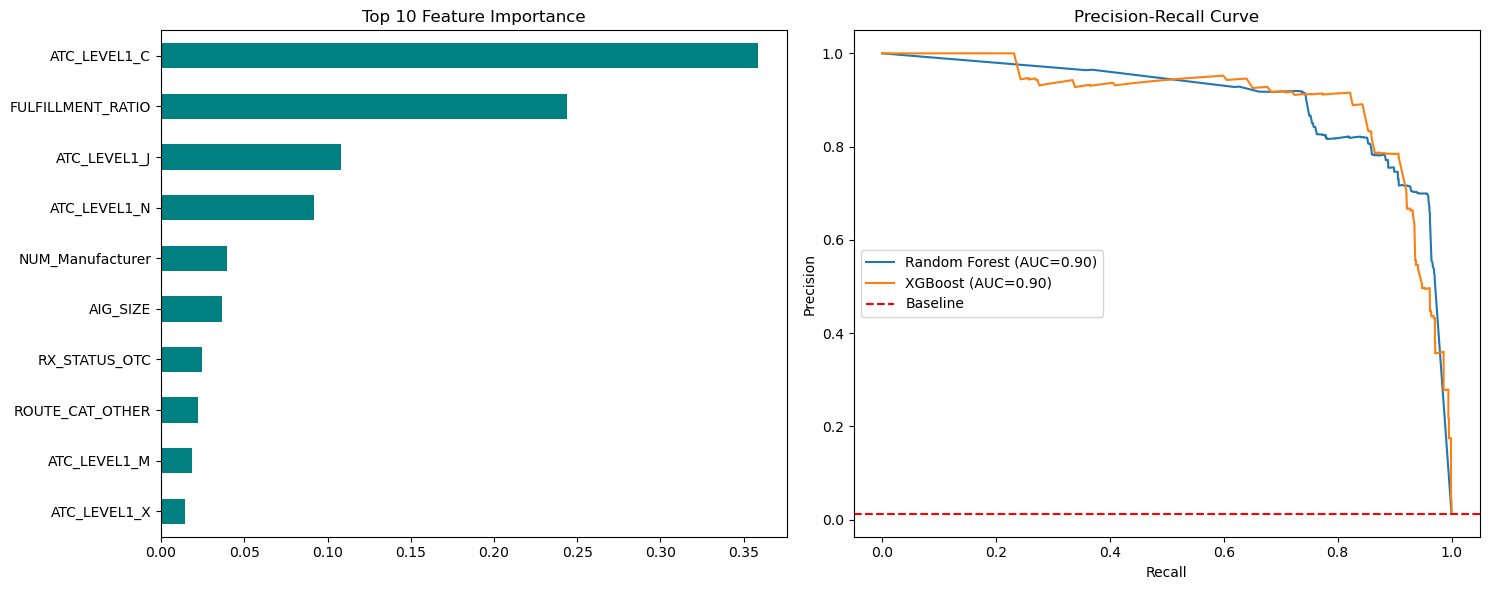

In [20]:
# ==============================================================================
# SECTION 6: MODEL TRAINING & EVALUATION (BUSINESS INTERPRETATION)
# ==============================================================================
print("="*70)
print("MCKESSON CAPSTONE: DRUG SHORTAGE PREDICTIVE SYSTEM")
print("="*70)
print(f"LOGIC CONFIRMATION:")
print(f"  > Inputs (X):   Week [T-1] data (Supply Gap, Sales, Trends, etc.)")
print(f"  > Target (Y):   Prediction for weeks [T+1] to [T+4]")
print(f"  > Gap Period:   Week [T] is the buffer for procurement action")
print("-" * 70)

from sklearn.metrics import classification_report, precision_recall_curve, auc, roc_auc_score

# 6.1 & 6.2 Training (Keep your existing fit logic)
# ------------------------------------------------------------------------------
print("Status: Training RF and XGBoost models...")
# ... (rf_model.fit and xgb_model.fit as before) ...

# 6.3 Enhanced Evaluation Function with Business Explanations
# ------------------------------------------------------------------------------
def evaluate_business_performance(model, X, y, name):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1]
    
    # Get raw metrics
    report = classification_report(y, preds, output_dict=True)
    shortage_metrics = report['1'] # Focus on Class 1 (Shortage)
    
    precision_vals, recall_vals, _ = precision_recall_curve(y, probs)
    pr_auc = auc(recall_vals, precision_vals)
    
    # --- Professional Print Output ---
    print(f"\n[MODEL REPORT: {name.upper()}]")
    print("-" * 40)
    
    # 1. Print Raw Report for reference
    print("Standard Metrics Table:")
    print(classification_report(y, preds))
    
    # 2. Print Plain English Interpretation
    rec = shortage_metrics['recall']
    pre = shortage_metrics['precision']
    
    print("BUSINESS INTERPRETATION (Class 1 - Shortage):")
    print(f"  > RECALL (Catch Rate): {rec:.1%}")
    print(f"    EXPLAIN: Out of all actual shortages that happened in the next 4 weeks,")
    print(f"             the model successfully identified {rec:.1%} of them using T-1 data.")
    
    print(f"\n  > PRECISION (Warning Accuracy): {pre:.1%}")
    print(f"    EXPLAIN: When the model issues a 'Shortage Warning', it is correct {pre:.1%} of")
    print(f"             the time. The remaining {1-pre:.1%} are precautionary false alarms.")
    
    print(f"\n  > PR-AUC (Overall Reliability): {pr_auc:.4f}")
    print(f"    EXPLAIN: A score of {pr_auc:.4f} indicates excellent handling of the 1.2% imbalanced data.")
    print("-" * 40)
    
    return precision_vals, recall_vals, pr_auc

# Run the enhanced evaluation
rf_pr = evaluate_business_performance(rf_model, X_test, y_test, "Random Forest")
xgb_pr = evaluate_business_performance(xgb_model, X_test, y_test, "XGBoost")

# 6.4 Visualization (Feature Importance & PR-Curve)
# ------------------------------------------------------------------------------
plt.figure(figsize=(15, 6))

# Plot 1: Feature Importance (XGBoost)
plt.subplot(1, 2, 1)
feat_imp = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False).head(10)
feat_imp.plot(kind='barh', color='teal')
plt.title('Top 10 Feature Importance') # Top importance features
plt.gca().invert_yaxis()

# Plot 2: Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(rf_pr[1], rf_pr[0], label=f'Random Forest (AUC={rf_pr[2]:.2f})')
plt.plot(xgb_pr[1], xgb_pr[0], label=f'XGBoost (AUC={xgb_pr[2]:.2f})')
plt.axhline(y=sum(y_test)/len(y_test), color='red', linestyle='--', label='Baseline')
plt.xlabel('Recall') # Measurement of sensitivity
plt.ylabel('Precision') # Measurement of accuracy
plt.title('Precision-Recall Curve') # Best for imbalance
plt.legend()

plt.tight_layout()
plt.savefig('Model_Performance_Comparison.png')
print("\nStatus: Evaluation complete. Plots saved.")